In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
p1g =pd.read_csv('../data/raw/Planta1_Generacion.csv')
p2g = pd.read_csv('../data/raw/Planta2_Generacion.csv')
p1s = pd.read_csv('../data/raw/Planta1_Sensores.csv')
p2s = pd.read_csv('../data/raw/Planta2_Sensores.csv')

In [3]:
# convertir 'fecha_hora' a datetime con dayfirst=True
p1g['fecha_hora'] = pd.to_datetime(p1g['fecha_hora'].astype(str).str.strip(), dayfirst=True, errors='coerce')

# fijar id_planta = 'p1' para todos los registros
p1g['id_planta'] = 'p1'

p1g.info()
p1g.head()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_hora          68778 non-null  datetime64[us]
 1   id_planta           68778 non-null  str           
 2   id_inversor         68778 non-null  str           
 3   potencia_dc_kw      68778 non-null  float64       
 4   potencia_ac_kw      68778 non-null  float64       
 5   energia_diaria_kwh  68778 non-null  float64       
 6   energia_total_kwh   68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 4.8 MB


,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
# convertir 'fecha_hora' a datetime con dayfirst=True
p2g['fecha_hora'] = pd.to_datetime(p2g['fecha_hora'], dayfirst=False)

# fijar id_planta = 'p1' para todos los registros
p2g['id_planta'] = 'p2'

# comprobación rápida
p2g.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,p2,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15,p2,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15,p2,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15,p2,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15,p2,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


In [5]:
p1s['fecha_hora']= pd.to_datetime(p1s['fecha_hora'], dayfirst=False)
p1s['id_planta'] = 'p1'

In [6]:
p2s['fecha_hora']= pd.to_datetime(p2s['fecha_hora'], dayfirst=False)
p2s['id_planta'] = 'p2'

In [7]:
#Análisis de regularidad de series temporales para detección de anomalías 
datasets = {
    'p1g': p1g,
    'p2g': p2g,
    'p1s': p1s,
    'p2s': p2s,
}

def summarize_dataset(df, name):
    s = df['fecha_hora']
    if not np.issubdtype(s.dtype, np.datetime64):
        s = pd.to_datetime(s.astype(str).str.strip(), dayfirst=True, errors='coerce')

    s = s.dropna().sort_values().drop_duplicates()
    diffs = s.diff().dropna()
    expected = pd.Timedelta(minutes=15)

    return {
        'dataset': name,
        'rows': len(df),
        'unique_timestamps': len(s),
        'start': s.iloc[0] if len(s) else pd.NaT,
        'end': s.iloc[-1] if len(s) else pd.NaT,
        'constant_interval': diffs.nunique() == 1 if len(diffs) else False,
        'min_step': diffs.min() if len(diffs) else None,
        'max_step': diffs.max() if len(diffs) else None,
        'expected_step_15min': expected,
        'interval_counts': diffs.value_counts().sort_index().to_dict(),
        'parse_failures': df['fecha_hora'].isna().sum() if np.issubdtype(df['fecha_hora'].dtype, np.datetime64) else pd.to_datetime(df['fecha_hora'].astype(str).str.strip(), dayfirst=True, errors='coerce').isna().sum(),
    }

summary = [summarize_dataset(df, name) for name, df in datasets.items()]
summary_df = pd.DataFrame(summary)
summary_df

,dataset,rows,unique_timestamps,start,end,constant_interval,min_step,max_step,expected_step_15min,interval_counts,parse_failures
0,p1g,68778,3158,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 09:00:00,0 days 00:15:00,"{0 days 00:15:00: 3148, 0 days 00:30:00: 2, 0 ...",0
1,p2g,67698,3259,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,"{0 days 00:15:00: 3253, 0 days 00:30:00: 5}",0
2,p1s,3182,3182,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 07:15:00,0 days 00:15:00,"{0 days 00:15:00: 3173, 0 days 00:30:00: 2, 0 ...",0
3,p2s,3259,3259,2020-05-15,2020-06-17 23:45:00,False,0 days 00:15:00,0 days 00:30:00,0 days 00:15:00,"{0 days 00:15:00: 3253, 0 days 00:30:00: 5}",0


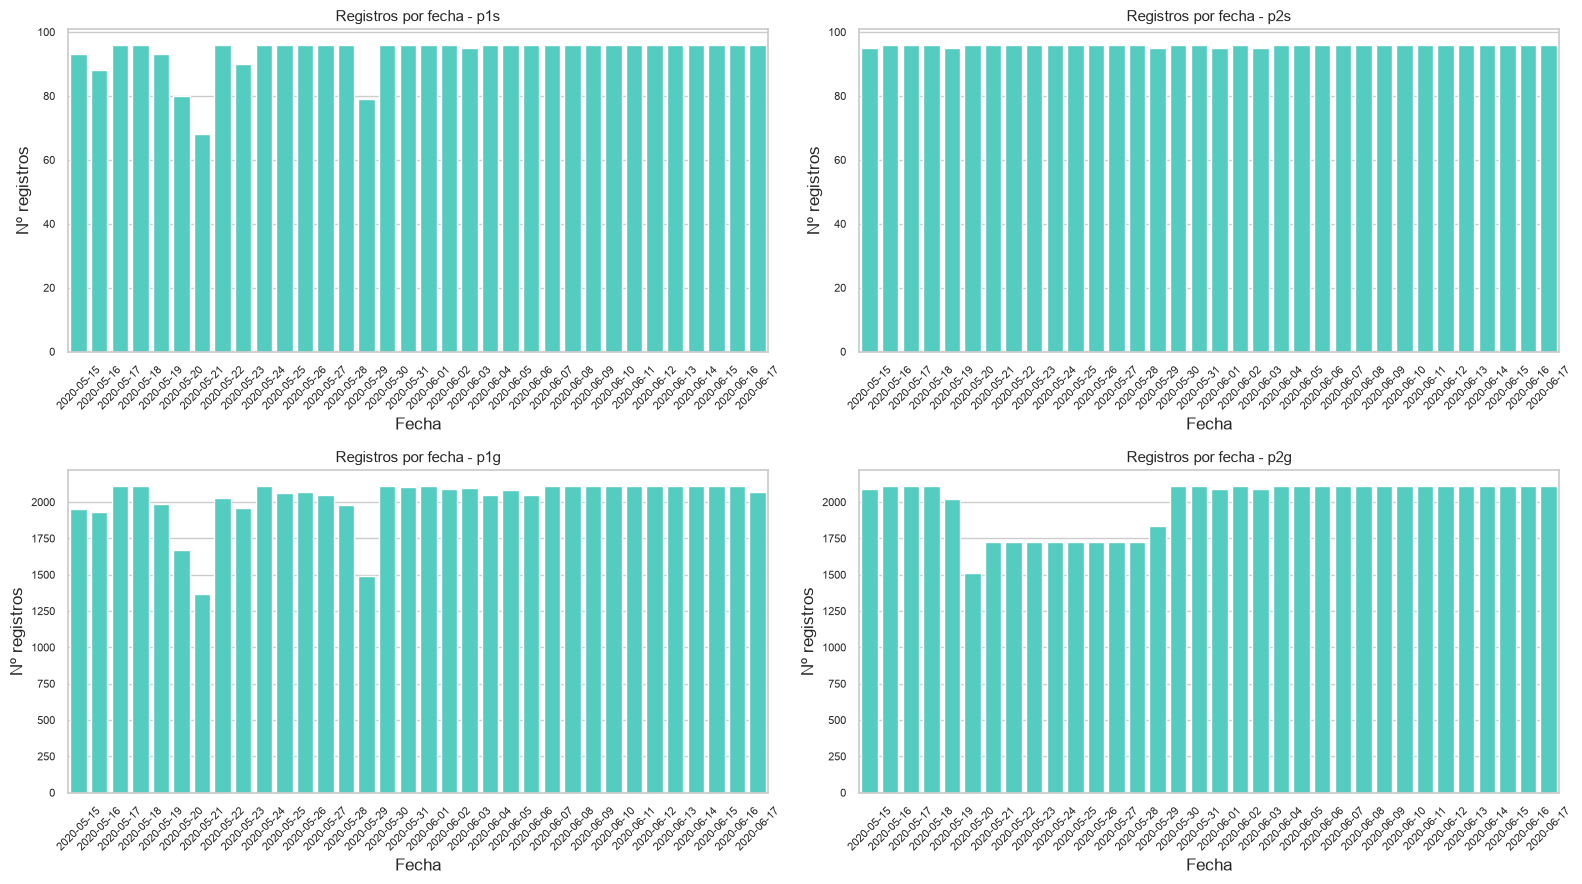

In [8]:
#Visualización de gaps temporales en los 4 datasets
datasets = {
    "p1s": p1s,
    "p2s": p2s,
    "p1g": p1g,
    "p2g": p2g,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    df = df.copy()
    df["fecha"] = df["fecha_hora"].dt.date

    daily_counts = df.groupby("fecha").size()

    sns.barplot(
        x=daily_counts.index,
        y=daily_counts.values,
        ax=ax,
        color="turquoise"
    )

    ax.set_title(f"Registros por fecha - {name}", fontsize=11)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Nº registros")

    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()


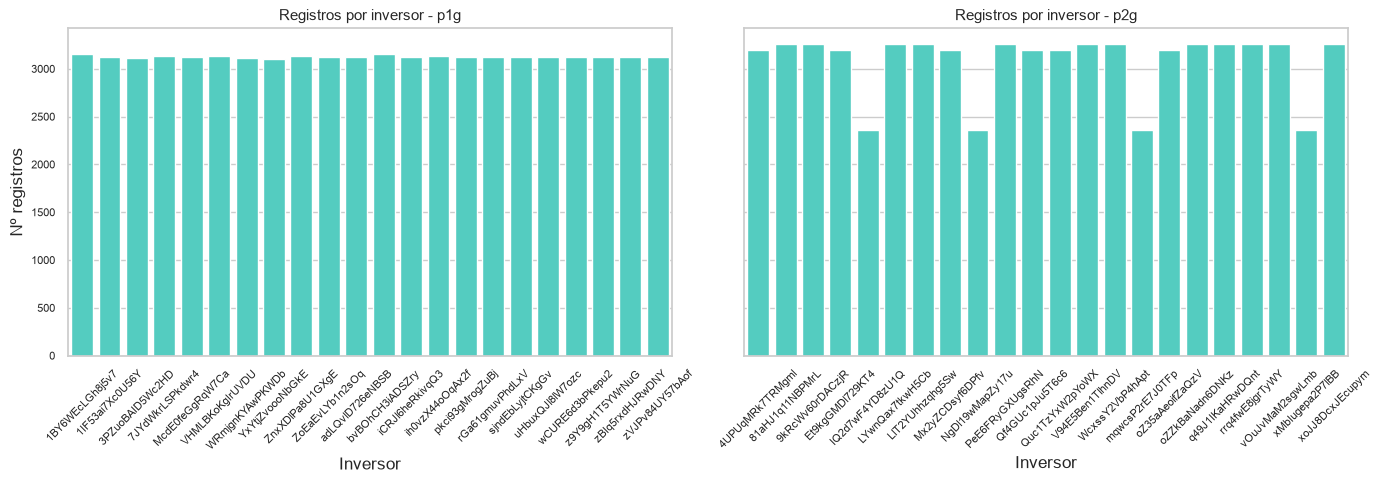

In [9]:
#Visualización de registros por inverter

datasets = {
    "p1g": p1g,
    "p2g": p2g,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (name, df) in zip(axes, datasets.items()):
    inverter_counts = df.groupby("id_inversor").size()

    sns.barplot(
        x=inverter_counts.index,
        y=inverter_counts.values,
        ax=ax,
        color="turquoise"
    )

    ax.set_title(f"Registros por inversor - {name}", fontsize=11)
    ax.set_xlabel("Inversor")
    ax.set_ylabel("Nº registros")

    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.show()

### Insights 1-2-3
1. El valor de los registros de DC en la planta 1 está a una escala 10 veces superior de lo que deberia, comparando con el resto de datos de la planta 2. Es muy probale que los errores sean de medicion y simplemente sea un problema de unidades al recoger los datos.
2. Tenemos irregularidades en los intervalos de las series temporales tanto para los datasets de generacion como de sensores: Faltan registros de intervalos de 15 minutos.
3. Algunos inverters de la planta 2 muestran ausencia notable de registros (en concreto 4 de ellos). Continuar profundizando en este análisis en la fase de EDA.

In [10]:
#crear datasets combinados de generacion y sensores por separado
gener = pd.concat([p1g, p2g], axis='index')
sensor = pd.concat([p1s, p2s], axis='index')

sensor.head()

,fecha_hora,id_planta,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2
0,2020-05-15 00:00:00,p1,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,p1,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,p1,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,p1,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,p1,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [11]:
#tabla combinada final: datos de generacion + sensores
df = pd.merge(gener, sensor, on=['fecha_hora', 'id_planta'], how='left')

In [14]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 136476 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_planta                136476 non-null  str    
 1   id_inversor              136476 non-null  str    
 2   potencia_dc_kw           136476 non-null  float64
 3   potencia_ac_kw           136476 non-null  float64
 4   energia_diaria_kwh       136476 non-null  float64
 5   energia_total_kwh        136476 non-null  float64
 6   id_sensor_meteorologico  136472 non-null  str    
 7   temperatura_ambiente_c   136472 non-null  float64
 8   temperatura_modulo_c     136472 non-null  float64
 9   irradiacion_wh_m2        136472 non-null  float64
dtypes: float64(7), str(3)
memory usage: 15.7 MB


In [ ]:
#Establecemos fecha_hora como index y eliminamos nulos ya que no afectan al analisis (4 nulos totales)
df.set_index('fecha_hora', inplace=True)
df = df.dropna()

In [18]:
#creamos objeto parquet
df.to_parquet('../data/intermediate/tablon_analitico_importacion.parquet')